# Time series
Have a look at the code below using generated temperature as sensor data. A Regressor should be used to forecast temperature.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

Creation of dataset:

In [11]:
# create synthetic time series of temperature
np.random.seed(42)
n = 500

time = np.arange(n)
amplitude = 20*np.random.choice(np.random.random_sample(size=5), size=n)
signal = np.sin(time * 0.03)*amplitude+np.random.randint(0, 10) # simulate temperature
noise = np.random.normal(0, 0.2, n)

y = signal + noise

df = pd.DataFrame({"y": y})
df.describe()

,y
count,500.000000
mean,4.281441
std,8.706293
min,-16.474090
25%,-1.609992
50%,4.955197
75%,10.326222
max,22.193727


Create features (lag features), feature matrix X and target vector y. 

In [12]:
df.head()

,y
0,2.945792
1,3.316512
2,4.260329
3,3.493500
4,4.074926


In [ ]:
# create lag features
df["lag1"] = df["y"].shift(1) #every datapoint has the history of the last three datapoints
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3)

df = df.dropna()

X = df[["lag1", "lag2", "lag3"]]
y = df["y"]



In [15]:
df.head()

,y,lag1,lag2,lag3
3,3.493500,4.260329,3.316512,2.945792
4,4.074926,3.493500,4.260329,3.316512
5,5.098401,4.074926,3.493500,4.260329
6,3.799624,5.098401,4.074926,3.493500
7,6.724384,3.799624,5.098401,4.074926


Train-test split! Note that instead of a random split, a simple temporal slicing is done!

In [16]:
# time based split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


Train a RF Regressor

In [5]:
# train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# predictions
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 4.613205133641321


<Axes: ylabel='y'>

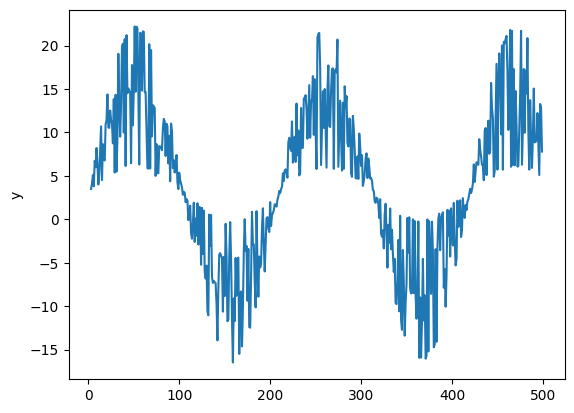

In [6]:
sns.lineplot(df["y"])

could be temp fluctuations 

Try to improve the accuracy of the Regressor by adding lag features or a rolling mean and rolling standard, play with the window and distances of lag features:

In [17]:
# create lag features
df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3)


df["rolling_mean_5"] = df["y"].rolling(window=5).mean()
df["rolling_std_5"] = df["y"].rolling(window=5).std()

df = df.dropna()

X = df[["lag1", "lag2", "lag3", "rolling_std_5", "rolling_mean_5"]] # add these feaxtueres
y = df["y"]

# time based split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]
df.head()

,y,lag1,lag2,lag3,rolling_mean_5,rolling_std_5
7,6.724384,3.799624,5.098401,4.074926,4.638167,1.312895
8,6.000190,6.724384,3.799624,5.098401,5.139505,1.243274
9,8.205119,6.000190,6.724384,3.799624,5.965544,1.661015
10,6.398484,8.205119,6.000190,6.724384,6.225560,1.591646
11,4.009372,6.398484,8.205119,6.000190,6.267510,1.512520


You can also try other Models (e.g. GradientBoostingRegressor or LinearRegression) and see how the RMSE behaves...

### Forecasting:

Assume you want to forecast the next three temperature points. There are two different ways to achieve that - recursive or direct. Have a look at the code below and discuss what it achieves:

In [ ]:
df = pd.DataFrame({"y": y})

df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3)

df["y_t1"] = df["y"].shift(-1) # Zukunft
df["y_t2"] = df["y"].shift(-2)
df["y_t3"] = df["y"].shift(-3)

df = df.dropna()

X = df[["lag1","lag2","lag3"]]

y1 = df["y_t1"]
y2 = df["y_t2"]
y3 = df["y_t3"]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

model1 = RandomForestRegressor().fit(X_train, y1[:split])
model2 = RandomForestRegressor().fit(X_train, y2[:split])
model3 = RandomForestRegressor().fit(X_train, y3[:split])

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

recursive approach

<Axes: >

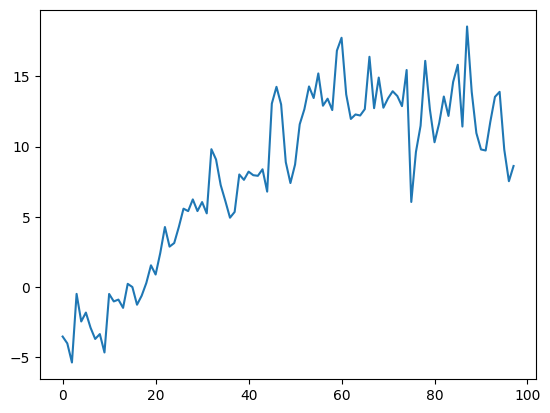

In [9]:
sns.lineplot(pred1)